# **XLM-RoBERTa**

## Import Libraries

In [1]:
# XLM-RoBERTa
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

# Utility Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime



# **SENTIMENT DATA PREPARATION**

**Sentiment Data**
- Scraped from Facebook
- Saved on Google Drive

In [2]:
# Updated data
file_id = '11uH44QHYYAdrXhTKN2yYCpA-lPEsEPdR'
url =  f'https://drive.google.com/uc?export=download&id={file_id}'

df = pd.read_csv(url)

def preprocess_df(df):
  df = df.dropna(subset=['comments']).reset_index(drop=True)
  df = df[['date','comments']]

  # Drop the NAT dates
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
  df = df.dropna(subset=['date']).reset_index(drop=True)

  # Sort the dataset by date
  df['date'] = df['date'].dt.date
  df = df.sort_values(by='date').reset_index(drop=True)

  return df

df = preprocess_df(df)

print(f"Total comments: {len(df)}")

df

Total comments: 17058


,date,comments
0,2020-01-05,Mali yan kawawa nanman ang magsisibuyas lalo s...
1,2020-01-05,"Ang hirap satin eh,,pag nagmahal ang isang bag..."
2,2020-01-05,Sen Marcos next month na anihan dito ng sebuya...
3,2020-01-05,Mam malapit na po ang anihan ng sebuyas wag na...
4,2020-01-05,Gawan nila na farmers cooperative na magbiyahe...
...,...,...
17053,2026-06-04,"Dito po sa palengke ng Santa Rosa, Nueva Ecija"
17054,2026-06-04,Dapat may ayoda rin yong walang bukid
17055,2026-06-04,DA inutil talaga kayo Bakit baliktad ang inves...
17056,2026-06-04,Mam Sana ung presyo nang baboy DN ang matutuka...


**Filter by Word Count**
- Word minimum: 5
- Word maximum: 400


In [3]:
def filter_by_word_count(df, min_len=5, max_len=400):
  df['clean_comments'] = df['comments'].str.replace(r'[^\w\s]', '', regex=True)
  word_count = df['clean_comments'].str.split().str.len()

  df_unfiltered = df.copy()
  df_filtered = df[word_count.between(min_len, max_len)].reset_index(drop=True)

  previous_len = len(df_unfiltered)
  new_len = len(df_filtered)

  print(f"Filtering Comments by Word Count ({min_len} to {max_len} words)")
  print(f"Total comments before filtering: {previous_len}")
  print(f"Total comments after filtering:  {new_len}")

  return df_filtered

df_filtered = filter_by_word_count(df,5, 400)

Filtering Comments by Word Count (5 to 400 words)
Total comments before filtering: 17058
Total comments after filtering:  14054


# **COMMENT DATA VISUALIZATION**

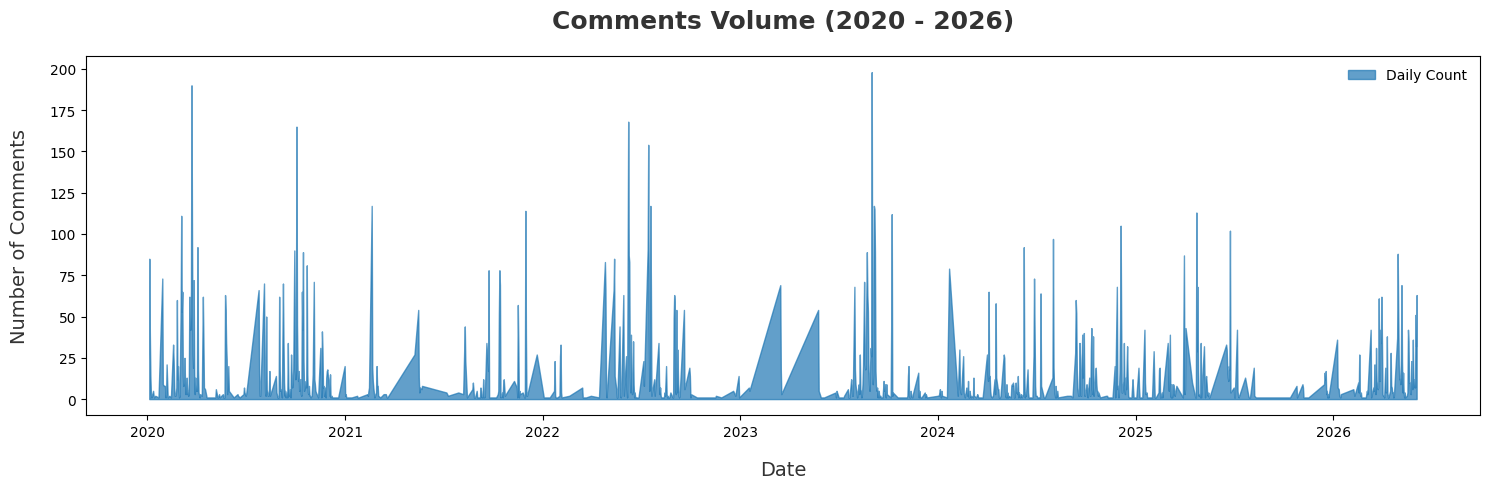

In [4]:

def display_comments_volume(df):
  daily_counts = df_filtered.groupby(df["date"]).size()
  daily_counts.index = pd.to_datetime(daily_counts.index)

  fig, ax = plt.subplots(figsize=(15, 5))

  ax.fill_between(
      daily_counts.index,
      daily_counts.values,
      color="#1f77b4",
      alpha=0.7,
      label="Daily Count"
  )


  ax.set_title("Comments Volume (2020 - 2026)", fontsize=18, pad=20, weight="bold", color="#333333")
  ax.set_xlabel("Date", fontsize=14, labelpad=15, color="#333333")
  ax.set_ylabel("Number of Comments", fontsize=14, labelpad=15, color="#333333")

  ax.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper right')

  plt.tight_layout()
  plt.show()

display_comments_volume(df_filtered)

# **LOADING XLM-RoBERTa MODEL**

**Loading transformer model**

In [5]:
SENTIMENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

print(f"Loading sentiment model: {SENTIMENT_MODEL}")
tokenizer_sent = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
model_sent     = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL)

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if device == 0 else 'CPU'}")


sentiment_pipe = pipeline(
    "text-classification",
    model=model_sent,
    tokenizer=tokenizer_sent,
    device=device,
    top_k=None,           # return all three label scores
    truncation=True,
    max_length=128,
)


Loading sentiment model: cardiffnlp/twitter-xlm-roberta-base-sentiment


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: CPU


**Classifying sentiment polarities with XLM-RoBERTa**

In [6]:
def run_sentiment(df, text_col, batch_size=32):
    sequences = df[text_col].tolist()
    all_results = []

    for start in range(0, len(sequences), batch_size):
        batch = sequences[start : start + batch_size]
        outputs = sentiment_pipe(batch)   # list of list-of-dicts
        for item in outputs:
            scores = {d['label']: d['score'] for d in item}
            all_results.append(scores)

        if (start // batch_size) % 10 == 0:
            print(f"  Processed {min(start + batch_size, len(sequences))}"
                  f" / {len(sequences)} sequences")

    result_df = df.copy()
    result_df['score_positive'] = [r.get('Positive', r.get('positive', 0.0)) for r in all_results]
    result_df['score_neutral']  = [r.get('Neutral',  r.get('neutral',  0.0)) for r in all_results]
    result_df['score_negative'] = [r.get('Negative', r.get('negative', 0.0)) for r in all_results]
    result_df['sentiment']      = result_df[['score_positive','score_neutral','score_negative']].idxmax(axis=1)
    result_df['sentiment']      = result_df['sentiment'].str.replace('score_', '')

    return result_df

In [7]:
# ── Run sentiment classification on dataset ───────────────────────────
print("Running sentiment classification...")
classified_sentiment = run_sentiment(df_filtered, "comments")

print(f"\nTotal records: {len(classified_sentiment)}")
print("\nSentiment distribution:")
print(classified_sentiment['sentiment'].value_counts())

# Save
classified_sentiment[
    ['date','comments', 'sentiment','score_positive','score_neutral','score_negative']
].to_csv('sentiments.csv', index=False)

Running sentiment classification...
  Processed 32 / 14054 sequences
  Processed 352 / 14054 sequences
  Processed 672 / 14054 sequences
  Processed 992 / 14054 sequences
  Processed 1312 / 14054 sequences
  Processed 1632 / 14054 sequences
  Processed 1952 / 14054 sequences
  Processed 2272 / 14054 sequences
  Processed 2592 / 14054 sequences
  Processed 2912 / 14054 sequences
  Processed 3232 / 14054 sequences
  Processed 3552 / 14054 sequences
  Processed 3872 / 14054 sequences
  Processed 4192 / 14054 sequences
  Processed 4512 / 14054 sequences
  Processed 4832 / 14054 sequences
  Processed 5152 / 14054 sequences
  Processed 5472 / 14054 sequences
  Processed 5792 / 14054 sequences
  Processed 6112 / 14054 sequences
  Processed 6432 / 14054 sequences
  Processed 6752 / 14054 sequences
  Processed 7072 / 14054 sequences
  Processed 7392 / 14054 sequences
  Processed 7712 / 14054 sequences
  Processed 8032 / 14054 sequences
  Processed 8352 / 14054 sequences
  Processed 8672 / 14054

**Sentiment Scores Processing:**
- Aggregate to daily frequency
- Label missing dates with 0.33 across positive, negative and neutral classes

In [21]:
import pandas as pd

# Aggregate scores to daily averages
df_sentiment = classified_sentiment.copy()
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# Average the three probability scores per day
df_sentiment_daily = (
    df_sentiment
    .groupby('date')[['score_positive', 'score_neutral', 'score_negative']]
    .mean()
    .rename_axis('Date')
)

# Determine the full date range
min_date = pd.to_datetime('2020-01-01') # Start from 2020-01-01 as requested
max_date = pd.to_datetime('2026-04-30') # User specified end date
full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

# Reindex to the full date range and fill missing dates with 0.33
df_sentiment_daily = df_sentiment_daily.reindex(full_date_range)
df_sentiment_daily[['score_positive', 'score_neutral', 'score_negative']] = df_sentiment_daily[['score_positive', 'score_neutral', 'score_negative']].fillna(0.33)

print(df_sentiment_daily.head())
print(df_sentiment_daily.tail())

            score_positive  score_neutral  score_negative
2020-01-01        0.330000       0.330000        0.330000
2020-01-02        0.330000       0.330000        0.330000
2020-01-03        0.330000       0.330000        0.330000
2020-01-04        0.330000       0.330000        0.330000
2020-01-05        0.153394       0.268535        0.578071
            score_positive  score_neutral  score_negative
2026-04-26        0.330000       0.330000        0.330000
2026-04-27        0.330000       0.330000        0.330000
2026-04-28        0.330000       0.330000        0.330000
2026-04-29        0.176443       0.350423        0.473135
2026-04-30        0.143443       0.301568        0.554989


# **EXPORT SENTIMENT DATA: UNTIL TEST SET**

In [22]:
import os

# Create a directory to save sentiment scores if it doesn't exist
sentiment_dir = 'sentiment_scores'
os.makedirs(sentiment_dir, exist_ok=True)

sentiment_file_path = os.path.join(sentiment_dir, 'daily_sentiment_scores.csv')
df_sentiment_daily.to_csv(sentiment_file_path)

print(f'Daily sentiment scores saved to {sentiment_file_path}')

Daily sentiment scores saved to sentiment_scores/daily_sentiment_scores.csv


# **EXPORT SENTIMENT DATA: DEMO SET**

In [20]:
# Aggregate scores to daily averages
df_sentiment_new_range = classified_sentiment.copy()
df_sentiment_new_range['date'] = pd.to_datetime(df_sentiment_new_range['date'])

# Average the three probability scores per day
df_sentiment_daily_new_range = (
    df_sentiment_new_range
    .groupby('date')[['score_positive', 'score_neutral', 'score_negative']]
    .mean()
    .rename_axis('Date')
)

# Determine the full date range for the new period
min_date_new = pd.to_datetime('2026-05-01') # Start from 2026-05-01
max_date_new = pd.to_datetime('2026-06-14') # End at 2026-06-14
full_date_range_new = pd.date_range(start=min_date_new, end=max_date_new, freq='D')

# Reindex to the full date range and fill missing dates with 0.33
df_sentiment_daily_new_range = df_sentiment_daily_new_range.reindex(full_date_range_new)
df_sentiment_daily_new_range[['score_positive', 'score_neutral', 'score_negative']] = df_sentiment_daily_new_range[['score_positive', 'score_neutral', 'score_negative']].fillna(0.33)

print(df_sentiment_daily_new_range.head())
print(df_sentiment_daily_new_range.tail())

            score_positive  score_neutral  score_negative
2026-05-01        0.145361       0.299615        0.555024
2026-05-02        0.146058       0.303177        0.550765
2026-05-03        0.052871       0.183185        0.763944
2026-05-04        0.075438       0.195501        0.729062
2026-05-05        0.176980       0.323381        0.499639
            score_positive  score_neutral  score_negative
2026-06-10            0.33           0.33            0.33
2026-06-11            0.33           0.33            0.33
2026-06-12            0.33           0.33            0.33
2026-06-13            0.33           0.33            0.33
2026-06-14            0.33           0.33            0.33


In [19]:
import os

# Create a directory to save sentiment scores if it doesn't exist
sentiment_dir = 'sentiment_scores'
os.makedirs(sentiment_dir, exist_ok=True)

sentiment_file_path_new_range = os.path.join(sentiment_dir, 'daily_sentiment_scores_new_range.csv')
df_sentiment_daily_new_range.to_csv(sentiment_file_path_new_range)

print(f'Daily sentiment scores for the new range saved to {sentiment_file_path_new_range}')

Daily sentiment scores for the new range saved to sentiment_scores/daily_sentiment_scores_new_range.csv


# **GOOGLE TRENDS DATA PREPARATION**

In [ ]:

file_id = '11eq35xy7sKF1Eho2xdxzI7_MYsEpASRU'
trends_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={file_id}')

trends_df




,Date,Search
0,2020-01-01,0
1,2020-01-02,12
2,2020-01-03,10
3,2020-01-04,14
4,2020-01-05,17
...,...,...
2349,2026-06-07,14
2350,2026-06-08,14
2351,2026-06-09,16
2352,2026-06-10,15


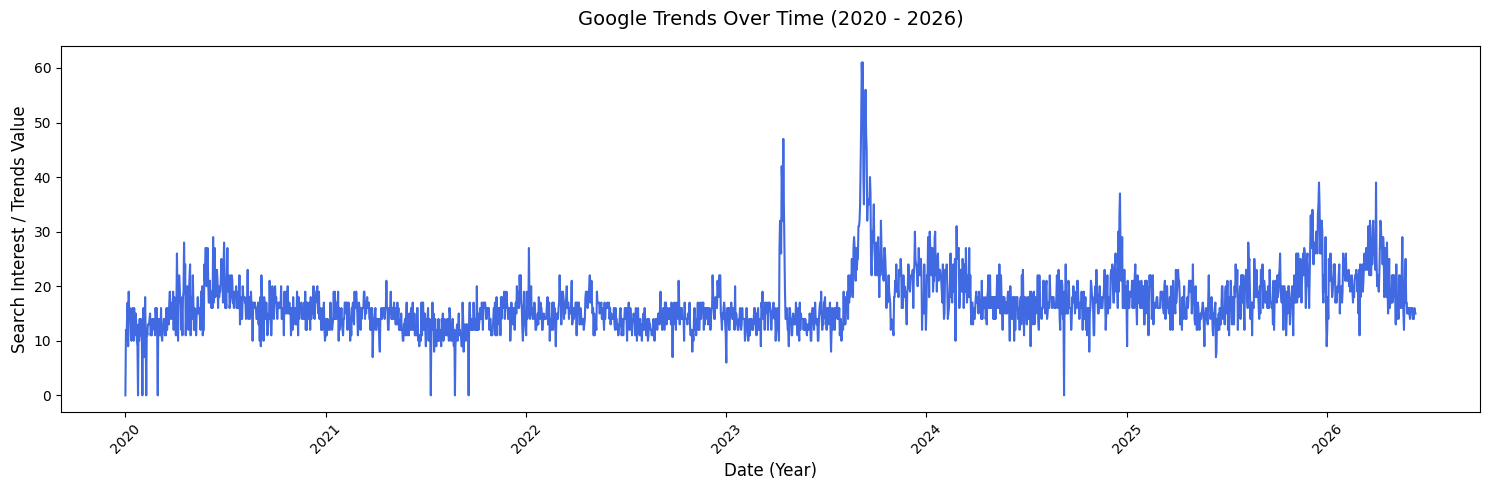

In [ ]:

# presyo ng bigas + price of rice + rice price + rice shortage + rice import + NFA rice price
trends_df['Date'] = pd.to_datetime(trends_df['Date'])
trends_df['Search'] = pd.to_numeric(trends_df['Search'])

plt.figure(figsize=(15, 5))

plt.plot(trends_df['Date'], trends_df['Search'], color='royalblue', linewidth=1.5, label='Search')

plt.title('Google Trends Over Time (2020 - 2026)', fontsize=14, pad=15)
plt.xlabel('Date (Year)', fontsize=12)
plt.ylabel('Search Interest / Trends Value', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()